In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shyamnadhs/heart-disease-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-prediction-dataset


In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset path
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Correcting the CSV file name to 'disease_prediction.csv'
dataset_file = os.path.join(path, 'disease_prediction.csv')

# Load the dataset
df = pd.read_csv(dataset_file)

# Display the first few rows and information about the dataset
print("\nDataset Head:")
display(df.head())
print("\nDataset Info:")
display(df.info())

Files in dataset directory: ['disease_prediction.csv']

Dataset Head:


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


None

In [ ]:
# Remove the 'patient_id' column as requested
if 'patient_id' in df.columns:
    df = df.drop('patient_id', axis=1)
    print("\n'patient_id' column removed. New DataFrame head:")
    display(df.head())
else:
    print("\n'patient_id' column not found in the dataset.")


'patient_id' column removed. New DataFrame head:


,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


Now, let's prepare the data for logistic regression. We'll separate features (X) and the target variable (y), then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# The target variable for heart disease prediction is 'disease'
X = df.drop('disease', axis=1)
y = df['disease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


Next, we will train a Logistic Regression model and evaluate its performance.

In [ ]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nLogistic Regression Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

ValueError: could not convert string to float: 'Male'

In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset path
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Correcting the CSV file name to 'disease_prediction.csv'
dataset_file = os.path.join(path, 'disease_prediction.csv')

# Load the dataset
df = pd.read_csv(dataset_file)

# Display the first few rows and information about the dataset
print("\nDataset Head:")
display(df.head())
print("\nDataset Info:")
display(df.info())

Files in dataset directory: ['disease_prediction.csv']

Dataset Head:


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


None

In [ ]:
# Remove the 'patient_id' column as requested
if 'patient_id' in df.columns:
    df = df.drop('patient_id', axis=1)
    print("\n'patient_id' column removed. New DataFrame head:")
    display(df.head())
else:
    print("\n'patient_id' column not found in the dataset.")


'patient_id' column removed. New DataFrame head:


,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


Now, let's prepare the data for logistic regression. We'll separate features (X) and the target variable (y), then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# The target variable for heart disease prediction is 'disease'
X = df.drop('disease', axis=1)
y = df['disease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


Next, we will train a Logistic Regression model and evaluate its performance.

In [ ]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nLogistic Regression Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

ValueError: could not convert string to float: 'Male'

In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset path
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Correcting the CSV file name to 'disease_prediction.csv'
dataset_file = os.path.join(path, 'disease_prediction.csv')

# Load the dataset
df = pd.read_csv(dataset_file)

# Display the first few rows and information about the dataset
print("\nDataset Head:")
display(df.head())
print("\nDataset Info:")
display(df.info())

Files in dataset directory: ['disease_prediction.csv']

Dataset Head:


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


None

In [ ]:
# Remove the 'patient_id' column as requested
if 'patient_id' in df.columns:
    df = df.drop('patient_id', axis=1)
    print("\n'patient_id' column removed. New DataFrame head:")
    display(df.head())
else:
    print("\n'patient_id' column not found in the dataset.")


'patient_id' column removed. New DataFrame head:


,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


Now, let's prepare the data for logistic regression. We'll separate features (X) and the target variable (y), then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# The target variable for heart disease prediction is 'disease'
X = df.drop('disease', axis=1)
y = df['disease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


Next, we will train a Logistic Regression model and evaluate its performance.

In [ ]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nLogistic Regression Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

ValueError: could not convert string to float: 'Male'

In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset path
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Correcting the CSV file name to 'disease_prediction.csv'
dataset_file = os.path.join(path, 'disease_prediction.csv')

# Load the dataset
df = pd.read_csv(dataset_file)

# Display the first few rows and information about the dataset
print("\nDataset Head:")
display(df.head())
print("\nDataset Info:")
display(df.info())

Files in dataset directory: ['disease_prediction.csv']

Dataset Head:


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


None

In [ ]:
# Remove the 'patient_id' column as requested
if 'patient_id' in df.columns:
    df = df.drop('patient_id', axis=1)
    print("\n'patient_id' column removed. New DataFrame head:")
    display(df.head())
else:
    print("\n'patient_id' column not found in the dataset.")


'patient_id' column removed. New DataFrame head:


,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


Now, let's prepare the data for logistic regression. We'll separate features (X) and the target variable (y), then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# The target variable for heart disease prediction is 'disease'
X = df.drop('disease', axis=1)
y = df['disease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


Next, we will train a Logistic Regression model and evaluate its performance.

In [ ]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nLogistic Regression Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

ValueError: could not convert string to float: 'Male'

In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset path
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Correcting the CSV file name to 'disease_prediction.csv'
dataset_file = os.path.join(path, 'disease_prediction.csv')

# Load the dataset
df = pd.read_csv(dataset_file)

# Display the first few rows and information about the dataset
print("\nDataset Head:")
display(df.head())
print("\nDataset Info:")
display(df.info())

Files in dataset directory: ['disease_prediction.csv']

Dataset Head:


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


None

In [ ]:
# Remove the 'patient_id' column as requested
if 'patient_id' in df.columns:
    df = df.drop('patient_id', axis=1)
    print("\n'patient_id' column removed. New DataFrame head:")
    display(df.head())
else:
    print("\n'patient_id' column not found in the dataset.")


'patient_id' column not found in the dataset.


Now, let's prepare the data for logistic regression. We'll separate features (X) and the target variable (y), then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# The target variable for heart disease prediction is 'disease'
X = df.drop('disease', axis=1)
y = df['disease']

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 13)
X_test shape: (200, 13)
y_train shape: (800,)
y_test shape: (200,)


Next, we will train a Logistic Regression model and evaluate its performance.

In [ ]:
# Initialize and train the Logistic Regression model
# Increased max_iter for convergence with larger feature set due to one-hot encoding
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nLogistic Regression Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)


Logistic Regression Model Accuracy: 0.8500

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.86       105
         Yes       0.87      0.81      0.84        95

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



In [ ]:
# Remove the 'patient_id' column as requested
if 'patient_id' in df.columns:
    df = df.drop('patient_id', axis=1)
    print("\n'patient_id' column removed. New DataFrame head:")
    display(df.head())
else:
    print("\n'patient_id' column not found in the dataset.")


'patient_id' column removed. New DataFrame head:


,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


Now, let's prepare the data for logistic regression. We'll separate features (X) and the target variable (y), then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# The target variable for heart disease prediction is 'disease'
X = df.drop('disease', axis=1)
y = df['disease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


Next, we will train a Logistic Regression model and evaluate its performance.

In [ ]:
model = LogisticRegression(max_iter=2000, random_state=42) # Increased max_iter for convergence after one-hot encoding
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nLogistic Regression Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)


Logistic Regression Model Accuracy: 0.8500

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.86       105
         Yes       0.87      0.81      0.84        95

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'], # 'liblinear' is good for small datasets, 'lbfgs' for larger ones
    'max_iter': [2000] # Keep max_iter consistent with previous successful runs
}

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"\nBest hyperparameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

print(f"\nLogistic Regression Model Accuracy (Tuned): {accuracy_tuned:.4f}")
print("\nClassification Report (Tuned):")
print(report_tuned)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best hyperparameters found: {'C': 0.1, 'max_iter': 2000, 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.8425

Logistic Regression Model Accuracy (Tuned): 0.8350

Classification Report (Tuned):
              precision    recall  f1-score   support

          No       0.83      0.86      0.85       105
         Yes       0.84      0.81      0.82        95

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200



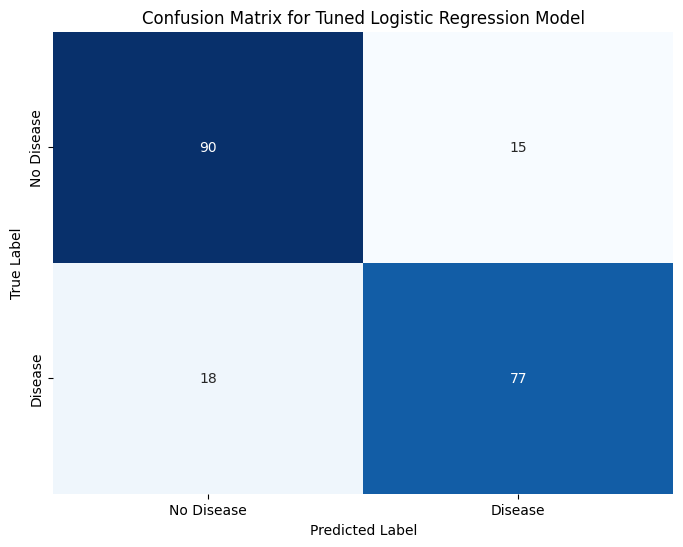

Interpretation of Confusion Matrix:
  - Top-left: True Negatives (Correctly predicted No Disease)
  - Top-right: False Positives (Incorrectly predicted Disease when there was None)
  - Bottom-left: False Negatives (Incorrectly predicted No Disease when there was Disease)
  - Bottom-right: True Positives (Correctly predicted Disease)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the tuned model
cm = confusion_matrix(y_test, y_pred_tuned)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix for Tuned Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Interpretation of Confusion Matrix:")
print("  - Top-left: True Negatives (Correctly predicted No Disease)")
print("  - Top-right: False Positives (Incorrectly predicted Disease when there was None)")
print("  - Bottom-left: False Negatives (Incorrectly predicted No Disease when there was Disease)")
print("  - Bottom-right: True Positives (Correctly predicted Disease)")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define an expanded parameter grid for Logistic Regression
# Exploring a wider range for C and adding 'penalty'
param_grid_expanded = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], # Wider range for regularization strength
    'penalty': ['l1', 'l2'], # L1 (Lasso) and L2 (Ridge) regularization
    'solver': ['liblinear', 'saga'], # 'liblinear' supports l1/l2, 'saga' supports l1/l2/elasticnet
    'max_iter': [2000] # Keep max_iter consistent
}

# Initialize Logistic Regression model
# Set a high max_iter as some solvers (like 'saga') might need more iterations
log_reg_expanded = LogisticRegression(random_state=42)

# Initialize GridSearchCV with the expanded parameter grid
grid_search_expanded = GridSearchCV(log_reg_expanded, param_grid_expanded, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_expanded.fit(X_train, y_train)

# Print the best parameters and best score from the expanded search
print(f"\nBest hyperparameters found (Expanded Search): {grid_search_expanded.best_params_}")
print(f"Best cross-validation accuracy (Expanded Search): {grid_search_expanded.best_score_:.4f}")

# Get the best model from the expanded search
best_model_expanded = grid_search_expanded.best_estimator_

# Make predictions on the test set with the new best model
y_pred_tuned_expanded = best_model_expanded.predict(X_test)

# Evaluate the new tuned model
accuracy_tuned_expanded = accuracy_score(y_test, y_pred_tuned_expanded)
report_tuned_expanded = classification_report(y_test, y_pred_tuned_expanded)

print(f"\nLogistic Regression Model Accuracy (Expanded Tuned): {accuracy_tuned_expanded:.4f}")
print("\nClassification Report (Expanded Tuned):")
print(report_tuned_expanded)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best hyperparameters found (Expanded Search): {'C': 10, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy (Expanded Search): 0.8388

Logistic Regression Model Accuracy (Expanded Tuned): 0.8600

Classification Report (Expanded Tuned):
              precision    recall  f1-score   support

          No       0.85      0.90      0.87       105
         Yes       0.88      0.82      0.85        95

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# Define a range of C values to test. These are inverse of regularization strength
# A smaller C means stronger regularization.
Cs = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Initialize LogisticRegressionCV model
# cv=5 for 5-fold cross-validation
# random_state for reproducibility
# solver and penalty are chosen based on common practice or previous good results
# max_iter is increased to ensure convergence, especially with higher C values
log_reg_cv = LogisticRegressionCV(Cs=Cs, cv=5, random_state=42, scoring='accuracy', n_jobs=-1, verbose=1, max_iter=2000,
                                  solver='liblinear', penalty='l1') # Using 'liblinear' with 'l1' for feature selection potential

# Fit the model to the training data
log_reg_cv.fit(X_train, y_train)

# Print the best C value found
print(f"\nBest C value found by LogisticRegressionCV: {log_reg_cv.C_[0]}")
print(f"Best cross-validation accuracy by LogisticRegressionCV: {log_reg_cv.score(X_train, y_train):.4f}")

# Make predictions on the test set with the best model found by LogisticRegressionCV
y_pred_cv = log_reg_cv.predict(X_test)

# Evaluate the model
accuracy_cv = accuracy_score(y_test, y_pred_cv)
report_cv = classification_report(y_test, y_pred_cv)

print(f"\nLogistic Regression Model Accuracy (LogisticRegressionCV): {accuracy_cv:.4f}")
print("\nClassification Report (LogisticRegressionCV):")
print(report_cv)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Best C value found by LogisticRegressionCV: 10.0
Best cross-validation accuracy by LogisticRegressionCV: 0.8450

Logistic Regression Model Accuracy (LogisticRegressionCV): 0.8600

Classification Report (LogisticRegressionCV):
              precision    recall  f1-score   support

          No       0.85      0.90      0.87       105
         Yes       0.88      0.82      0.85        95

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.8s finished


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Re-create X and y from the original df (after patient_id removal but before manual one-hot encoding)
# This is necessary to correctly identify numerical and categorical columns for the ColumnTransformer
df_processed = df.copy() # Make a copy to avoid modifying the global df for this step

# Identify numerical and categorical features
numerical_features = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()

# Remove the target variable 'disease' from features if it's there
if 'disease' in categorical_features:
    categorical_features.remove('disease')

# Define the target variable y
y_discretized = df_processed['disease']
# Define the features X_discretized
X_discretized = df_processed[numerical_features + categorical_features]

# Split data before preprocessing to prevent data leakage
X_train_disc, X_test_disc, y_train_disc, y_test_disc = train_test_split(X_discretized, y_discretized, test_size=0.2, random_state=42)


# Create a preprocessing pipeline for numerical features (KBinsDiscretizer)
# Strategy='quantile' ensures each bin has roughly the same number of samples
numerical_transformer = Pipeline(steps=[
    ('discretizer', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'))
])

# Create a preprocessing pipeline for categorical features (OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any other columns that are not specified
)

# Create the full pipeline with preprocessing and Logistic Regression model
model_discretized_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

# Train the model
model_discretized_pipeline.fit(X_train_disc, y_train_disc)

# Make predictions
y_pred_discretized = model_discretized_pipeline.predict(X_test_disc)

# Evaluate the model
accuracy_discretized = accuracy_score(y_test_disc, y_pred_discretized)
report_discretized = classification_report(y_test_disc, y_pred_discretized)

print(f"\nLogistic Regression Model Accuracy (with KBinsDiscretizer): {accuracy_discretized:.4f}")
print("\nClassification Report (with KBinsDiscretizer):")
print(report_discretized)


Logistic Regression Model Accuracy (with KBinsDiscretizer): 0.9250

Classification Report (with KBinsDiscretizer):
              precision    recall  f1-score   support

          No       0.91      0.95      0.93       105
         Yes       0.94      0.89      0.92        95

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.92       200



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform
from sklearn.metrics import accuracy_score, classification_report

# Define the parameter distributions for SGDClassifier
# alpha is the regularization strength
param_distributions_sgd = {
    'sgd_clf__alpha': loguniform(0.00001, 1), # A wide range for alpha
    'sgd_clf__penalty': ['l1', 'l2', 'elasticnet'],
    'sgd_clf__max_iter': [2000, 5000, 10000],
    'sgd_clf__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'sgd_clf__eta0': [0.01, 0.1, 0.5] # Initial learning rate for constant, invscaling, adaptive
}

# Create a pipeline with StandardScaler and SGDClassifier
sgd_pipeline_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd_clf', SGDClassifier(loss='log_loss', tol=1e-3, random_state=42))
])

# Initialize RandomizedSearchCV for the SGD pipeline
random_search_sgd = RandomizedSearchCV(
    sgd_pipeline_tuned,
    param_distributions_sgd,
    n_iter=50, # Number of random parameter combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit RandomizedSearchCV to the training data
random_search_sgd.fit(X_train, y_train)

# Print the best parameters and best score from the randomized search
print(f"\nBest hyperparameters found (SGD Randomized Search): {random_search_sgd.best_params_}")
print(f"Best cross-validation accuracy (SGD Randomized Search): {random_search_sgd.best_score_:.4f}")

# Get the best model from the randomized search
best_sgd_model = random_search_sgd.best_estimator_

# Make predictions on the test set with the new best model
y_pred_sgd_tuned = best_sgd_model.predict(X_test)

# Evaluate the new tuned model
accuracy_sgd_tuned = accuracy_score(y_test, y_pred_sgd_tuned)
report_sgd_tuned = classification_report(y_test, y_pred_sgd_tuned)

print(f"\nSGD Logistic Regression Model Accuracy (Tuned via Randomized Search): {accuracy_sgd_tuned:.4f}")
print("\nClassification Report (SGD Logistic Regression - Tuned):")
print(report_sgd_tuned)
print("\nNote: For binary classification, 'accuracy' is equivalent to 'micro avg'.")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best hyperparameters found (SGD Randomized Search): {'sgd_clf__alpha': np.float64(0.020540519425388443), 'sgd_clf__eta0': 0.1, 'sgd_clf__learning_rate': 'optimal', 'sgd_clf__max_iter': 5000, 'sgd_clf__penalty': 'l2'}
Best cross-validation accuracy (SGD Randomized Search): 0.8425

SGD Logistic Regression Model Accuracy (Tuned via Randomized Search): 0.8550

Classification Report (SGD Logistic Regression - Tuned):
              precision    recall  f1-score   support

          No       0.85      0.88      0.86       105
         Yes       0.86      0.83      0.84        95

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200


Note: For binary classification, 'accuracy' is equivalent to 'micro avg'.


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Create a pipeline with StandardScaler and SGDClassifier
# loss='log_loss' makes it a Logistic Regression model
# penalty='l2' for L2 regularization, alpha is the regularization strength
# max_iter is the number of passes over the training data (epochs)
# eta0 is the initial learning rate
# random_state for reproducibility
sgd_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd_clf', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001, max_iter=2000, tol=1e-3, random_state=42))
])

# Train the SGD Logistic Regression model
sgd_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_sgd = sgd_pipeline.predict(X_test)

# Evaluate the model
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
report_sgd = classification_report(y_test, y_pred_sgd)

print(f"\nSGD Logistic Regression Model Accuracy: {accuracy_sgd:.4f}")
print("\nClassification Report (SGD Logistic Regression):")
print(report_sgd)



SGD Logistic Regression Model Accuracy: 0.8250

Classification Report (SGD Logistic Regression):
              precision    recall  f1-score   support

          No       0.81      0.88      0.84       105
         Yes       0.85      0.77      0.81        95

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200

